# Heston — Method Comparison

| Method | Trainer | Notes |
|---|---|---|
| **Delta LSMC** | — | Regression-based delta baseline |
| **Delta CF** | — | Exact Heston delta (slow) |
| **DH** | DeepHedging | Plain MLP |
| **DH-PAF** | DeepHedging | PAF embedding |
| **DH-PnL** | DeepHedging | MLP + running P&L feature |
| **DH-PAF-PnL** | DeepHedging | PAF + P&L |
| **DH-SAC** | SAC | Entropy regularisation |

## 0. Setup

In [1]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.samplers      import HestonSampler
from src.metrics       import SoftMin
from src.backtest      import torch_backtest
from src.models        import ModelConfig
from src.trainers      import (TrainerConfig, DeepHedgingTrainer, SACTrainer,
                               DeviationTrainer)
from src.deltas        import LSMCDeltaHedger, HestonCFDeltaHedger
from src.logging_utils import save_log

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Parameters

In [2]:
# ── market ────────────────────────────────────────────────
S0    = 100.0
v0    = 0.04
r     = 0.01
kappa = 2.0
theta = 0.04
xi    = 0.1
rho   = -0.7
T     = 1.0
N     = 30
K     = 100.0
cost  = 1e-3
a     = 1.0

# ── training ──────────────────────────────────────────────
M_train  = 3_000
M_val    = 5_000   # validation paths (used for early stopping & best model)
M_test   = 5_000   # held-out test paths (evaluated once at the end)
n_epochs = 10_000
log_every           = 200
early_stop_patience = 100  # val checks without improvement → stop
lr                  = 1e-3

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── paths ─────────────────────────────────────────────────
sampler = HestonSampler(
    S0=S0, v0=v0, r=r, kappa=kappa,
    theta=theta, xi=xi, rho=rho, T=T, N=N
)

np.random.seed(42)
paths_val    = sampler.sample(M_val)
paths_test   = sampler.sample(M_test)
paths_val_t  = torch.tensor(paths_val,  dtype=torch.float32, device=DEVICE)
paths_test_t = torch.tensor(paths_test, dtype=torch.float32, device=DEVICE)

results = {}  # name -> {pnl, fees, log}

## 2. Helpers

In [3]:
def softmin_np(pnl: np.ndarray, a: float = a) -> float:
    return float(np.log(np.exp(-a * pnl).mean()) / a)

def record(name: str, pnl: np.ndarray, fees: np.ndarray, log: list = []):
    results[name] = {'pnl': pnl, 'fees': fees, 'log': log}
    print(f"  {name:<22}  SoftMin={softmin_np(pnl):>8.4f}  "
          f"mean={pnl.mean():>7.4f}  std={pnl.std():>6.4f}")
    # сохраняем всегда, для baseline пишем одну запись с финальным результатом
    summary = [{"epoch": 0, "val_loss": softmin_np(pnl),
                "elapsed": 0.0, "mean_pnl": float(pnl.mean()),
                "std_pnl": float(pnl.std())}] if not log else log
    save_log(summary, os.path.join(RESULTS_DIR, name.replace(' ', '_')))

def run_trainer(trainer, name: str):
    log       = trainer.fit()
    pnl, fees = trainer.eval_on_test()
    record(name, pnl, fees, log)

def base_cfg(**overrides) -> TrainerConfig:
    """TrainerConfig with shared defaults."""
    defaults = dict(
        n_epochs=n_epochs, M_train=M_train,
        log_every=log_every,
        early_stop_patience=early_stop_patience,
        lr=lr,
    )
    return TrainerConfig(**{**defaults, **overrides})


def make_trainer(TrainerClass, cfg, **kwargs):
    return TrainerClass(
        cfg=cfg,
        sampler=sampler,
        paths_val_t=paths_val_t,
        paths_test_t=paths_test_t,
        device=DEVICE,
        risk_aversion=a,
        K=K,
        cost=cost,
        **kwargs
    )


print('Helpers ready.')

Helpers ready.


## 3. Delta LSMC baseline

In [4]:
lsmc = LSMCDeltaHedger(K=K, cost=cost)
lsmc.fit(sampler.sample(10_000))
pnl, fees = lsmc.backtest(paths_test)
record('Delta LSMC', pnl, fees)

  Delta LSMC              SoftMin=  9.9928  mean=-8.0929  std=2.1338


## 4. Delta CF baseline

In [ ]:
M_test_cf = M_test

cf = HestonCFDeltaHedger(
    K=K, r=r, kappa=kappa, theta=theta,
    xi=xi, rho=rho, T=T, N=N, cost=cost
)
pnl, fees = cf.backtest(paths_test[:M_test_cf])
record('Delta CF', pnl, fees)

CF delta:   0%|          | 0/30 [00:00<?, ?it/s]

CF delta: 100%|██████████| 30/30 [31:18<00:00, 62.62s/it]

  Delta CF                SoftMin=  9.5526  mean=-8.1252  std=1.4872


## 5. DH — plain MLP

In [6]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)))),
    'DH'
)

Trainable parameters: 4,545


100%|██████████| 10000/10000 [34:43<00:00,  4.80it/s] 

  DH                      SoftMin= 10.2071  mean=-8.1151  std=2.4699


## 6. DH-PAF

In [7]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'))),
    'DH-PAF'
)

Trainable parameters: 4,289


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [39:33<00:00,  4.21it/s]

  DH-PAF                  SoftMin=  9.2568  mean=-8.1276  std=1.5427


## 7. DH-PnL

In [10]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)), use_pnl=True)),
    'DH-PnL'
)

Trainable parameters: 4,609


100%|██████████| 10000/10000 [36:28<00:00,  4.57it/s]

  DH-PnL                  SoftMin=  9.8449  mean=-8.0943  std=2.0792


## 8. DH-PAF-PnL

In [4]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True)),
    'DH-PAF-PnL'
)

Trainable parameters: 4,305


100%|██████████| 10000/10000 [57:42<00:00,  2.89it/s] 

  DH-PAF-PnL              SoftMin= 26.1345  mean=-8.1845  std=6.3497


## 9. DH-SAC

In [5]:
run_trainer(
    make_trainer(SACTrainer,
                 base_cfg(model=ModelConfig(arch='paf'),
                          beta_start=0.05, beta_end=0.001)),
    'DH-SAC'
)

Trainable parameters: 4,289


100%|██████████| 10000/10000 [41:05<00:00,  4.06it/s] 

  DH-SAC                  SoftMin=  9.2438  mean=-8.1351  std=1.5321


## 10. DH-PAF-PnL Pretrain Without PnL

In [6]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True, pnl_start_epoch = 2000)),
    'DH-PAF-PnL-Pretrain'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [1:10:23<00:00,  2.37it/s]

  DH-PAF-PnL-Pretrain     SoftMin= 31.8407  mean=-8.4726  std=7.0638


## 11. Delta PnL Deviation Runner

In [7]:

# Heston (sigma_const=None → берём sqrt(v_t))
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation'
)

Trainable parameters: 4,305


100%|██████████| 10000/10000 [43:36<00:00,  3.82it/s] 

  DH-Deviation            SoftMin=  9.1788  mean=-8.1255  std=1.4474


## 12. Summary table

In [12]:
import glob, json

def load_results(results_dir: str) -> dict:
    """Load all saved logs from results_dir into results dict."""
    loaded = {}
    for fpath in sorted(glob.glob(os.path.join(results_dir, '*.json'))):
        name = os.path.splitext(os.path.basename(fpath))[0].replace('_', ' ')
        with open(fpath) as f:
            log = json.load(f)
        # baseline записи имеют mean_pnl/std_pnl, восстанавливаем заглушку
        loaded[name] = {
            'pnl':  None,
            'fees': None,
            'log':  log,
        }
    return loaded


results = load_results(RESULTS_DIR)

In [13]:
print(f"\n{'Method':<24} {'SoftMin':>10} {'PnL mean':>10} {'PnL std':>9} {'Fees mean':>10}")
print('─' * 68)
for name, res in results.items():
    log = res.get('log', [])
    if res['pnl'] is not None:
        pnl, fees = res['pnl'], res['fees']
        print(f"{name:<24} {softmin_np(pnl):>10.4f} {pnl.mean():>10.4f} "
              f"{pnl.std():>9.4f} {fees.mean():>10.4f}")
    elif log:
        # берём последнюю запись из лога
        last = log[-1]
        sm   = last.get('val_loss', float('nan'))
        mean = last.get('mean_pnl', float('nan'))
        std  = last.get('std_pnl',  float('nan'))
        print(f"{name:<24} {sm:>10.4f} {mean:>10.4f} {std:>9.4f} {'n/a':>10}")


Method                      SoftMin   PnL mean   PnL std  Fees mean
────────────────────────────────────────────────────────────────────
DH-Deviation                 9.1394        nan       nan        n/a
DH-PAF-PnL-Pretrain         68.5777        nan       nan        n/a
DH-PAF-PnL                  70.2367        nan       nan        n/a
DH-PAF                       9.2245        nan       nan        n/a
DH-PnL                       9.5796        nan       nan        n/a
DH-SAC                       9.1518        nan       nan        n/a
DH                          10.1924        nan       nan        n/a
Delta CF                     9.5526    -8.1252    1.4872        n/a
Delta LSMC                   9.9928    -8.0929    2.1338        n/a


## 13. Learning curves

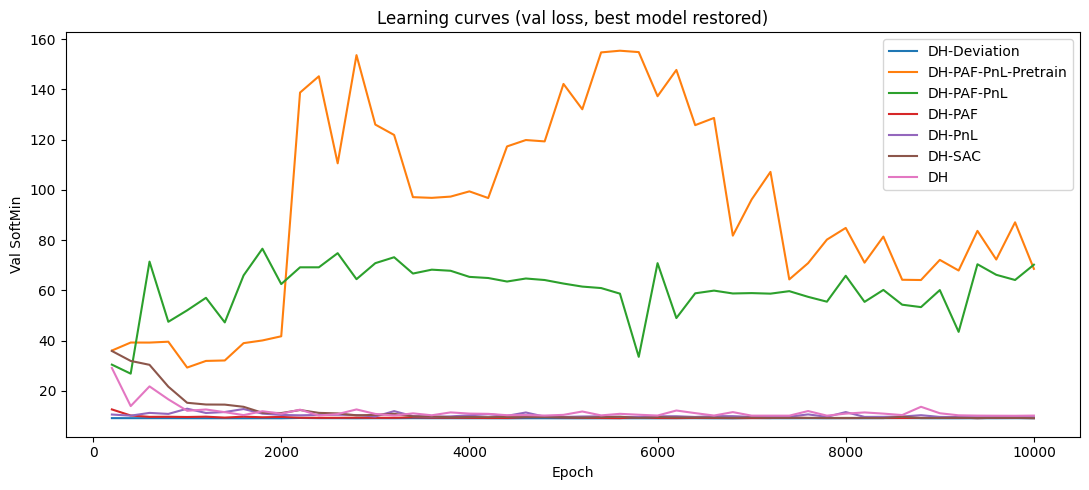

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    log = res.get('log', [])
    # фильтруем baseline (одна запись с epoch=0)
    log = [e for e in log if e.get('epoch', 0) > 0]
    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves (val loss, best model restored)')
ax.legend()
plt.tight_layout()
plt.show()

DH-Deviation [{'epoch': 200, 'val_loss': 9.177774429321289, 'elapsed': 54.36645812000097}, {'epoch': 400, 'val_loss': 9.167169570922852, 'elapsed': 106.03578069100149}, {'epoch': 600, 'val_loss': 9.167224884033203, 'elapsed': 157.07948838000084}, {'epoch': 800, 'val_loss': 9.170156478881836, 'elapsed': 210.08097140000064}, {'epoch': 1000, 'val_loss': 9.152755737304688, 'elapsed': 261.83916351800144}, {'epoch': 1200, 'val_loss': 9.143969535827637, 'elapsed': 312.5852351550002}, {'epoch': 1400, 'val_loss': 9.135616302490234, 'elapsed': 363.5926173780008}, {'epoch': 1600, 'val_loss': 9.128376960754395, 'elapsed': 415.79614955500074}, {'epoch': 1800, 'val_loss': 9.142765045166016, 'elapsed': 467.2847890390003}, {'epoch': 2000, 'val_loss': 9.127571105957031, 'elapsed': 519.2850187160002}, {'epoch': 2200, 'val_loss': 9.249698638916016, 'elapsed': 573.9509076250015}, {'epoch': 2400, 'val_loss': 9.163076400756836, 'elapsed': 627.2779801060005}, {'epoch': 2600, 'val_loss': 9.15683364868164, 'el

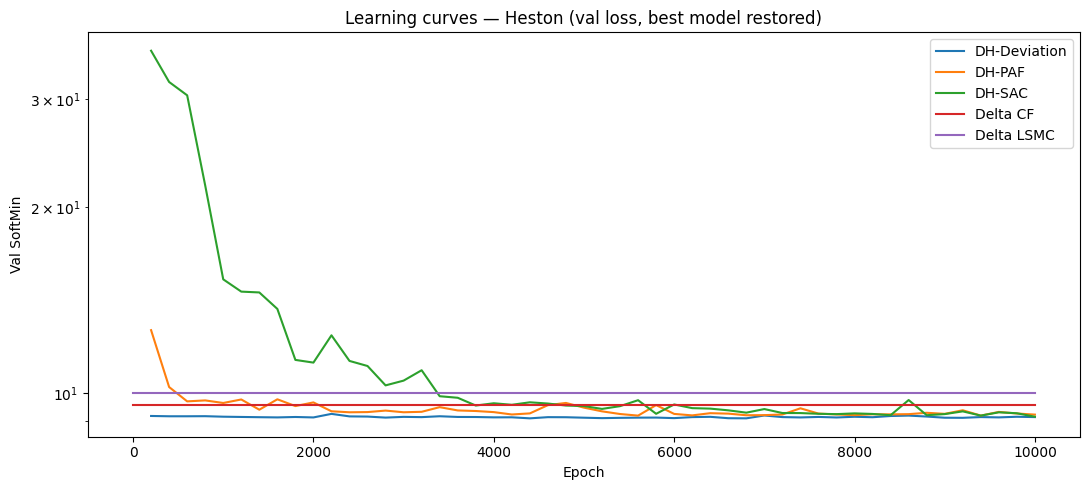

In [ ]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

DH-Deviation [{'epoch': 200, 'val_loss': 9.177774429321289, 'elapsed': 54.36645812000097}, {'epoch': 400, 'val_loss': 9.167169570922852, 'elapsed': 106.03578069100149}, {'epoch': 600, 'val_loss': 9.167224884033203, 'elapsed': 157.07948838000084}, {'epoch': 800, 'val_loss': 9.170156478881836, 'elapsed': 210.08097140000064}, {'epoch': 1000, 'val_loss': 9.152755737304688, 'elapsed': 261.83916351800144}, {'epoch': 1200, 'val_loss': 9.143969535827637, 'elapsed': 312.5852351550002}, {'epoch': 1400, 'val_loss': 9.135616302490234, 'elapsed': 363.5926173780008}, {'epoch': 1600, 'val_loss': 9.128376960754395, 'elapsed': 415.79614955500074}, {'epoch': 1800, 'val_loss': 9.142765045166016, 'elapsed': 467.2847890390003}, {'epoch': 2000, 'val_loss': 9.127571105957031, 'elapsed': 519.2850187160002}, {'epoch': 2200, 'val_loss': 9.249698638916016, 'elapsed': 573.9509076250015}, {'epoch': 2400, 'val_loss': 9.163076400756836, 'elapsed': 627.2779801060005}, {'epoch': 2600, 'val_loss': 9.15683364868164, 'el

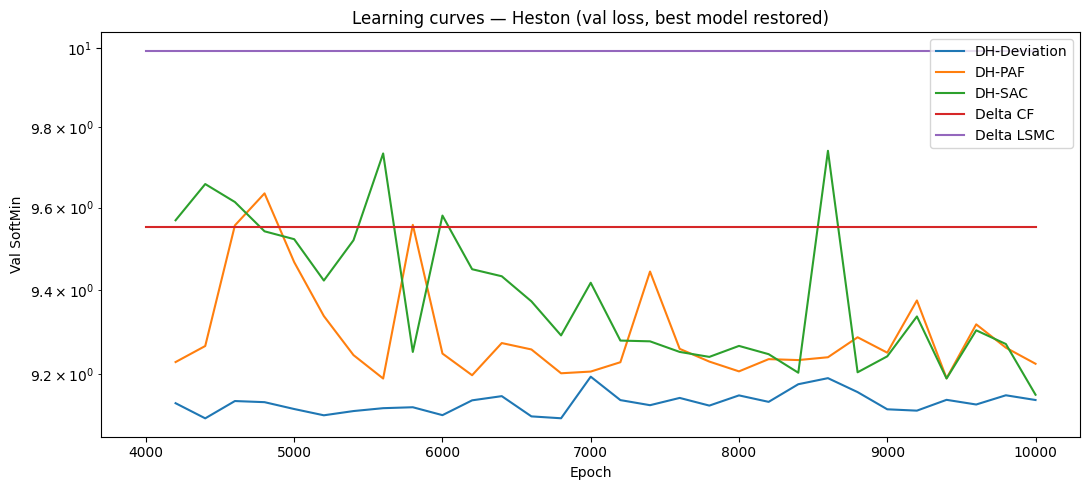

In [22]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    log = log[20:]

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Results

- Deep Hedging (DH) > Delta Hedging with compatible speed on Heston
- DH > Delta Hedging on GBM (where Delta is optimal)
- PAF > No-PAF
- Adding PnL requires some tricks like predicting deviation from delta. Perhaps using true Heston Delta instead of GBM proxy would lead to better result but would require to train a full NN to predict delta.
- SAC gives improvement but they feel random unlike in DH-deviation (see plot above)
- Other improvements like K-FAC were not yet considered


---


- Overall this work is a part of my GQW and overall what I did there is more like an article and less of "article implementation", but I found no real "other RL algorithms" to compete with MCPG here, if something is worse than DH - I would just skip it.

1. Вам необходимо выбрать и реализовать алгоритм, предложенный в статье на ваш выбор, и провести ряд экспериментов из этого исследования. Учитывая ограничения на компьют и время, необязательно проводить все эксперименты, упомянутые в статье. Выберите 2 - 5 экспериментов, которые считаете наиболее релевантными, приведите аргументы, почему были выбраны именно они, и проведите их. Другие методы из статьи, с которым сравнивается основной метод, реализовывать не нужно.
2. Цель всего задания - имплементировать понравившийся алгоритм и доказать его работоспособность на каком минимальном наборе сред/бенчмарков (или наоборот, такое тоже бывает). Затем представить краткий отчет по вашим экспериментам в свободной форме и записать десятиминутное видео, в котором рассказать суть статьи, официально объявленные результаты, как они соотносятся с вашими экспериментами, и поделиться любыми другими впечатлениями и наблюдениями, которые вы сделали в процессе реализации или чтения статьи.
3. Можно объединяться в группу до 2-х человек.
4. Задание весит 25% от всей оценки за курс.
5. Дедлайн на сдачу - последнее занятие курса, 09:00, 25 марта. Сдать надо будет код (который можно запустить) и отчет в формате ipynb/pdf + видео. Авторский код использовать можно, но главное это читаемый код экспериментов, который можно было перезапустить при желании, их описание + результаты.
6. Оценка выставляется по 10-балльной шкале: 6 баллов за код и отчет + 4 балла за видео.
7. Ограничение на видео - 10 минут."		